In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### Getting the data

In [2]:
df = pd.read_csv('data.csv')
df[:10]

,reaction_score,game_score,accuracy,stroop_error_rate,stroop_accuracy,go_nogo_accuracy,go_nogo_error_rate,memory_score,attention_score,problem_solving_score,quiz_score,risk_level
0,0.6910,0.8423,0.8967,0.1204,0.8451,0.8385,0.0671,0.7653,0.6571,0.8765,28,Low
1,0.6581,0.7708,0.7516,0.0548,0.9159,1.0000,0.1058,0.8386,0.8039,0.7680,28,Low
2,0.4581,0.5671,0.6373,0.2496,0.6616,0.6811,0.1688,0.6983,0.8600,0.6874,21,Moderate
3,0.8505,0.7494,0.7850,0.1109,0.8477,0.7892,0.0548,0.7509,0.8494,0.8507,28,Low
4,0.2834,0.2701,0.3593,0.4950,0.4676,0.4313,0.5090,0.2781,0.4068,0.3537,8,High
5,0.2939,0.4396,0.5071,0.6086,0.4156,0.4321,0.4470,0.2365,0.4234,0.4023,12,High
6,0.4790,0.6395,0.6630,0.2159,0.7201,0.7427,0.2906,0.6283,0.7335,0.5958,20,Moderate
7,0.8339,0.9092,0.8625,0.0000,0.9007,0.8463,0.0784,0.8617,0.8284,0.8250,24,Low
8,0.7785,0.7029,0.8156,0.0403,0.8861,0.8440,0.0636,0.8303,0.8734,0.7919,26,Low
9,0.3863,0.5114,0.4580,0.2957,0.6041,0.4639,0.4569,0.5924,0.5714,0.3695,26,Moderate


#### Veriying the data does side one type of label

In [3]:
low_count = len(df[df['risk_level'] == 'Low'])
moderate_count = len(df[df['risk_level'] == 'Moderate'])
high_count = len(df[df['risk_level'] == 'High'])

print(f'High: {high_count}\nModerate: {moderate_count}\nLow: {low_count}')
print(df['risk_level'].value_counts())

High: 437
Moderate: 775
Low: 788
risk_level
Low         788
Moderate    775
High        437
Name: count, dtype: int64


### Splitting the data into labels and features

In [4]:
X = df[['reaction_score', 'game_score', 'accuracy', 'stroop_error_rate',
        'stroop_accuracy', 'go_nogo_accuracy', 'go_nogo_error_rate',
        'memory_score', 'attention_score', 'problem_solving_score', 'quiz_score']].values
y = df['risk_level']
X.shape

(2000, 11)

### Setting the labels to 0 - 2 (integers)

In [5]:
label_map = {'Low': 0, 'Moderate': 1, 'High': 2}
y = y.map(label_map)

### Splitting the data into the 80% training and 20% testing format

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 )

### Creating the model

In [7]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Getting scores and report

Accuracy: 0.9675
Classification Report:
              precision    recall  f1-score   support

         Low       1.00      0.98      0.99       141
    Moderate       0.92      1.00      0.96       155
        High       1.00      0.90      0.95       104

    accuracy                           0.97       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.97      0.97      0.97       400



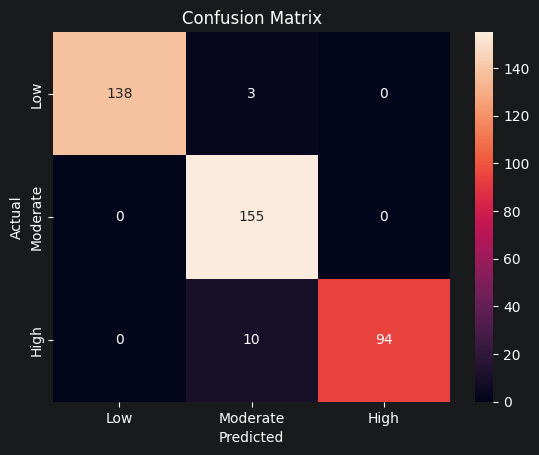

In [8]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['Low', 'Moderate', 'High'])
print(f'Accuracy: {accuracy}\nClassification Report:\n{classification_rep}')
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Low', 'Moderate', 'High'],
            yticklabels=['Low', 'Moderate', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Exporting the model

In [9]:
joblib.dump(model, 'cognify_model.pkl')

['cognify_model.pkl']